In [35]:
import pandas as pd
import missingno as msno

In [36]:
items_file_path = '../data/raw/olist_order_items_dataset.csv'
items = pd.read_csv(items_file_path)
items.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


# Products

In [37]:
products_file_path = '../data/raw/olist_products_dataset.csv'
products = pd.read_csv(products_file_path)
products.head()

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0


## Check duplicate

In [38]:
products[products.duplicated()]

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm


## Check data type

In [39]:
products.dtypes

product_id                        str
product_category_name             str
product_name_lenght           float64
product_description_lenght    float64
product_photos_qty            float64
product_weight_g              float64
product_length_cm             float64
product_height_cm             float64
product_width_cm              float64
dtype: object

## Check Null

In [40]:
(products.isnull().sum() / len(products) * 100).round(2)

product_id                    0.00
product_category_name         1.85
product_name_lenght           1.85
product_description_lenght    1.85
product_photos_qty            1.85
product_weight_g              0.01
product_length_cm             0.01
product_height_cm             0.01
product_width_cm              0.01
dtype: float64

## Check outlier

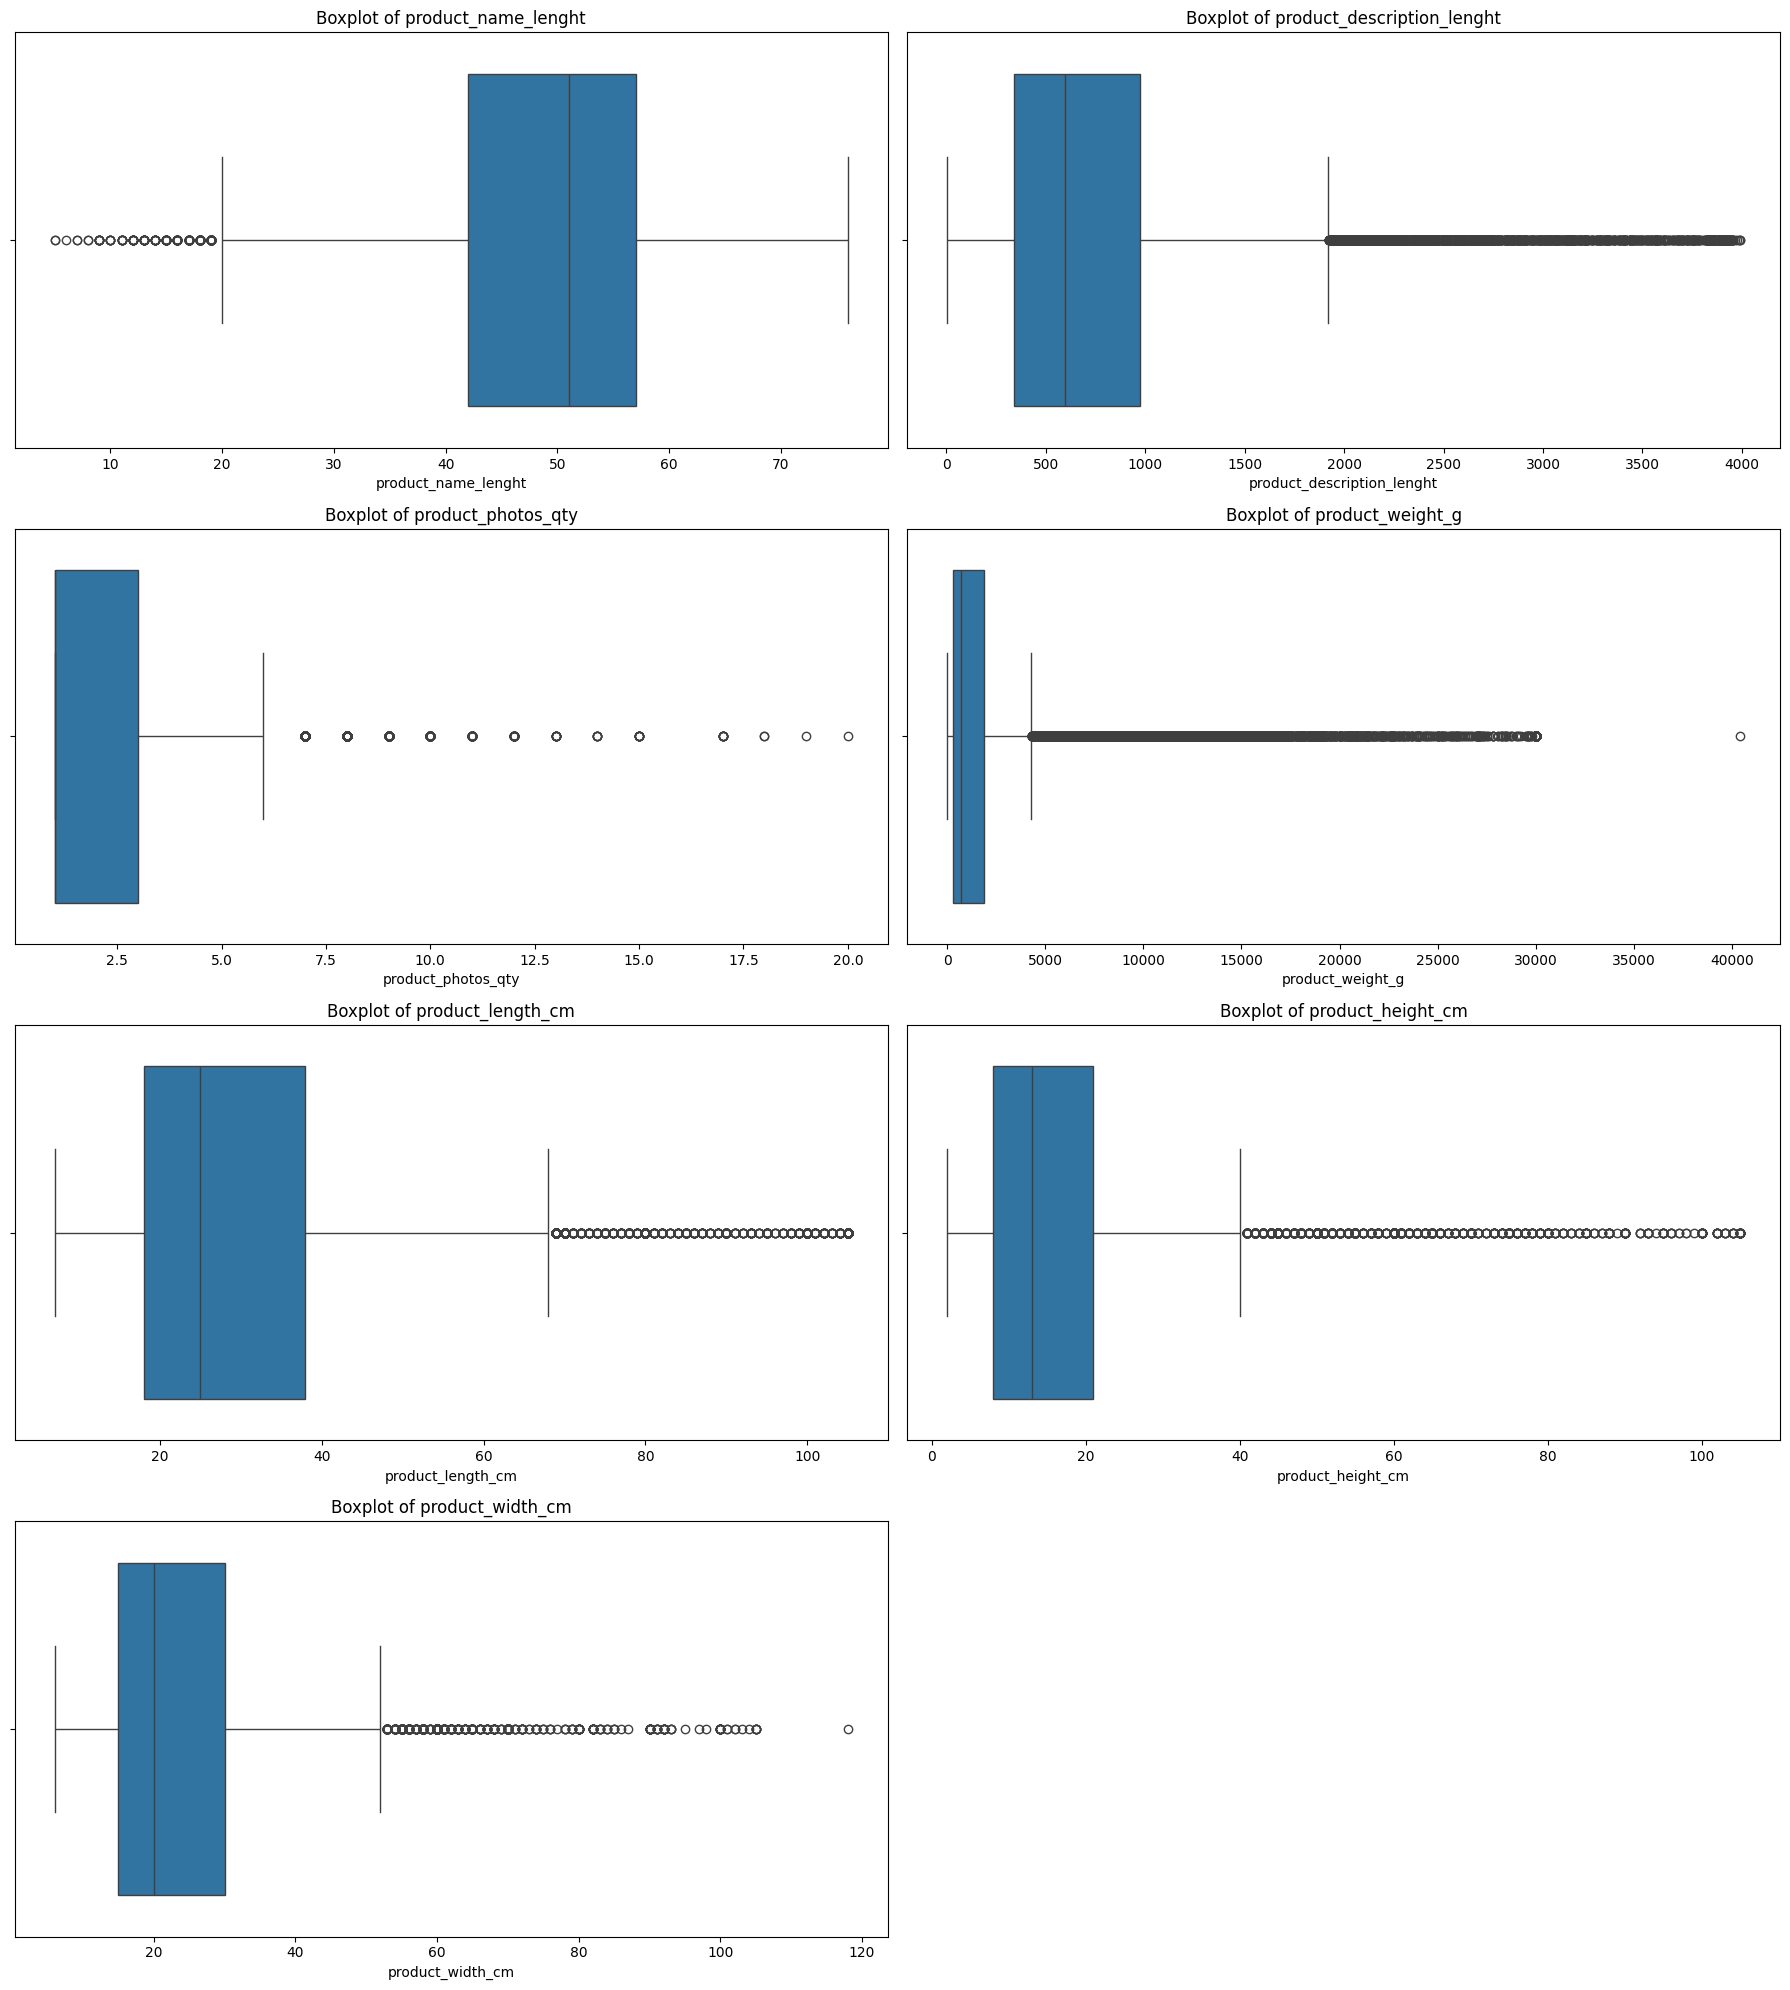

In [41]:
import matplotlib.pyplot as plt
import seaborn as sns

cols = [
    "product_name_lenght",
    "product_description_lenght",
    "product_photos_qty",
    "product_weight_g",
    "product_length_cm",
    "product_height_cm",
    "product_width_cm"
]
fig, axes = plt.subplots(nrows=4, ncols=2, figsize=(18, 20))
axes = axes.flatten()

for i, col in enumerate(cols):
    sns.boxplot(x=products[col], ax=axes[i])
    axes[i].set_title(f"Boxplot of {col}")

# Xóa ô thừa
fig.delaxes(axes[-1])

plt.tight_layout()
plt.show()

Check outlier product_weight_g

In [42]:
products[products['product_weight_g'] > 30000]

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
25166,26644690fde745fc4654719c3904e1db,cama_mesa_banho,59.0,534.0,1.0,40425.0,13.0,65.0,28.0


Với product_category_name cama_mesa_banho là bed_bath_table kích thước 13x65x28 mà weight 40425.0 g thì không hợp lý. Nghi vấn đây là anomaly

In [43]:
items[items["product_id"]=="26644690fde745fc4654719c3904e1db"]

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
32763,4a45f9f66971302cf881ecfa142f42ba,1,26644690fde745fc4654719c3904e1db,1835b56ce799e6a4dc4eddc053f04066,2017-12-29 19:13:20,80.0,16.32
48753,6ecf1a4051b4c5ed613624b460970a26,1,26644690fde745fc4654719c3904e1db,1835b56ce799e6a4dc4eddc053f04066,2017-11-23 08:55:48,80.0,12.06
63982,9223919b300f6989e1715333fca0d6ce,1,26644690fde745fc4654719c3904e1db,1835b56ce799e6a4dc4eddc053f04066,2018-03-07 23:15:32,80.0,16.32


Với weight cao như vậy mà price và freight_value thấp nên check với product có weight > 25000

In [44]:
products[products['product_weight_g'] > 25000]

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
148,8d6cb00151d423c52855385c89f0bae8,automotivo,58.0,386.0,1.0,27100.0,50.0,50.0,50.0
344,d0877f0094337c414d23f5a3c7bad20c,moveis_escritorio,48.0,489.0,2.0,30000.0,50.0,50.0,30.0
509,53f92b0474f91fcb5bd188c6a8075c38,utilidades_domesticas,54.0,2952.0,3.0,30000.0,76.0,51.0,51.0
955,ceeba7d5636e59173cc5f484e913db3d,NaN,NaN,NaN,NaN,30000.0,65.0,65.0,65.0
1159,f97ad9066c718a6cef93dfcf253d3e0d,moveis_decoracao,63.0,886.0,5.0,30000.0,61.0,70.0,65.0
...,...,...,...,...,...,...,...,...,...
31654,3b85e44a54ca23950c469c7fb1cc0e0a,beleza_saude,42.0,1580.0,1.0,30000.0,30.0,88.0,22.0
32179,d7f8b7443f6ae5796dabe493521a1e79,industria_comercio_e_negocios,56.0,2029.0,2.0,30000.0,105.0,43.0,46.0
32262,ebf1c13032246ea801765e8cb5417365,casa_construcao,39.0,1190.0,2.0,30000.0,50.0,80.0,50.0
32491,2b752ed328ea866e4721ca4e236a416c,moveis_cozinha_area_de_servico_jantar_e_jardim,47.0,2201.0,4.0,30000.0,16.0,2.0,11.0


In [45]:
items[items["product_id"]=="f97ad9066c718a6cef93dfcf253d3e0d"]

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
105386,ef6572468642ad6f224c1991a17bc4a6,1,f97ad9066c718a6cef93dfcf253d3e0d,11305281b50fff20ae8bb473f8e11876,2017-12-08 20:35:22,399.99,113.38


In [46]:
items[items["product_id"]=="d0877f0094337c414d23f5a3c7bad20c"]

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
9708,163f8eb1b8e1a57c3ff383c09e13d42c,1,d0877f0094337c414d23f5a3c7bad20c,656591be56071d4c9ef4e5fee78a578a,2017-04-19 16:10:10,430.0,45.47
94703,d6c877d8995925578fdeb1d186915549,1,d0877f0094337c414d23f5a3c7bad20c,656591be56071d4c9ef4e5fee78a578a,2017-05-11 13:10:37,430.0,27.52


Với weight > 25000 thường thì price và freight_value sẽ cao nên kết luận product 26644690fde745fc4654719c3904e1db weight product_weight_g = 40425.0
có thể là anomaly. Hướng xử lý điền meadian product_weight_g theo product_category_name	cama_mesa_banho

In [47]:
median_weight = products.loc[
    (products["product_category_name"] == "cama_mesa_banho") &
    (products["product_weight_g"] != 40425.0),
    "product_weight_g"
].median()

products.loc[
    products["product_weight_g"] == 40425.0,
    "product_weight_g"
] = median_weight

In [48]:
products[products["product_id"]=="26644690fde745fc4654719c3904e1db"]

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
25166,26644690fde745fc4654719c3904e1db,cama_mesa_banho,59.0,534.0,1.0,1250.0,13.0,65.0,28.0


Check outlier product_width_cm

Giá trị này product_width_cm = 118 là bình thường

In [49]:
products[products['product_width_cm'] > 110]

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
26970,b17808303e15dd50538c011b44295427,cama_mesa_banho,56.0,502.0,3.0,1050.0,23.0,93.0,118.0


Check outlier product_photos_qty

In [50]:
products[products['product_photos_qty'] > 15]

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
967,f9aa001a859b11fd798bb386f3d07eb0,pet_shop,54.0,802.0,17.0,9000.0,33.0,30.0,44.0
2112,26f4f1d683f32cfce93292cc626d5eea,pet_shop,53.0,823.0,17.0,1150.0,21.0,17.0,30.0
2196,7f38cf4e517ec6bb1d31c4e6b6df18ef,pet_shop,56.0,834.0,17.0,2000.0,33.0,30.0,44.0
9022,f95d5d21561ea085ba1e1a4e53840844,brinquedos,62.0,679.0,20.0,8900.0,32.0,49.0,34.0
11009,28763a4fd1b597a9c4f31a9579e7d1b4,pet_shop,53.0,823.0,17.0,1150.0,21.0,17.0,30.0
15735,801f0a5ea1ac28df44d65195cf4e2620,pet_shop,56.0,834.0,17.0,7300.0,33.0,30.0,44.0
17843,e9880042522806f124fdd4f8c8514d0d,pet_shop,54.0,830.0,18.0,2600.0,33.0,30.0,44.0
19056,234495ab7809d4517bc1330c439da1bb,bebes,63.0,659.0,19.0,8900.0,32.0,49.0,34.0
22005,5948868c402a614a2dd3b90ebb06a253,pet_shop,53.0,795.0,17.0,1100.0,21.0,17.0,30.0
24522,b085d8c8840e8dd3d6ccdf3d86c6145e,pet_shop,53.0,823.0,17.0,1050.0,21.0,17.0,30.0


Giá trị này bình thường

## Check correlation missing theo cặp các biến

<Axes: >

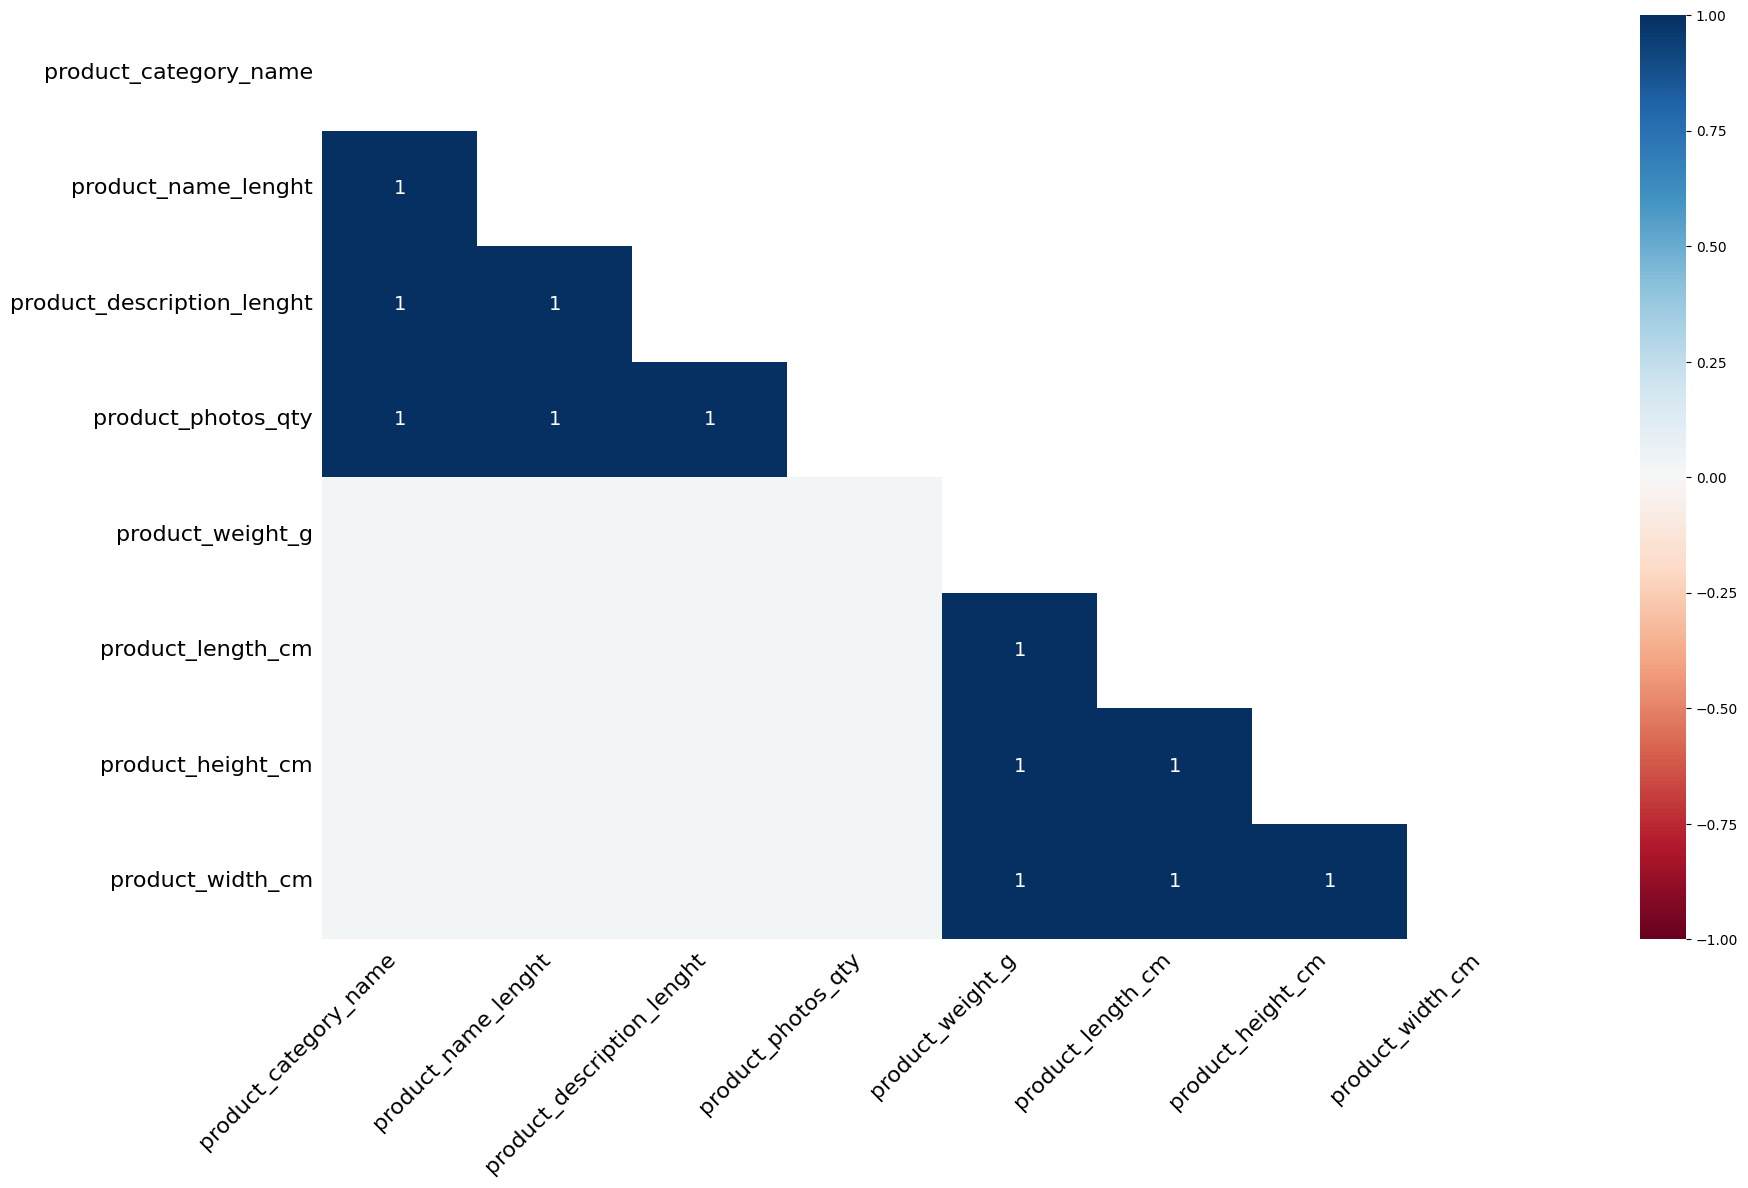

In [51]:
msno.heatmap(products)

## Check correlation missing nhóm các biến

<Axes: >

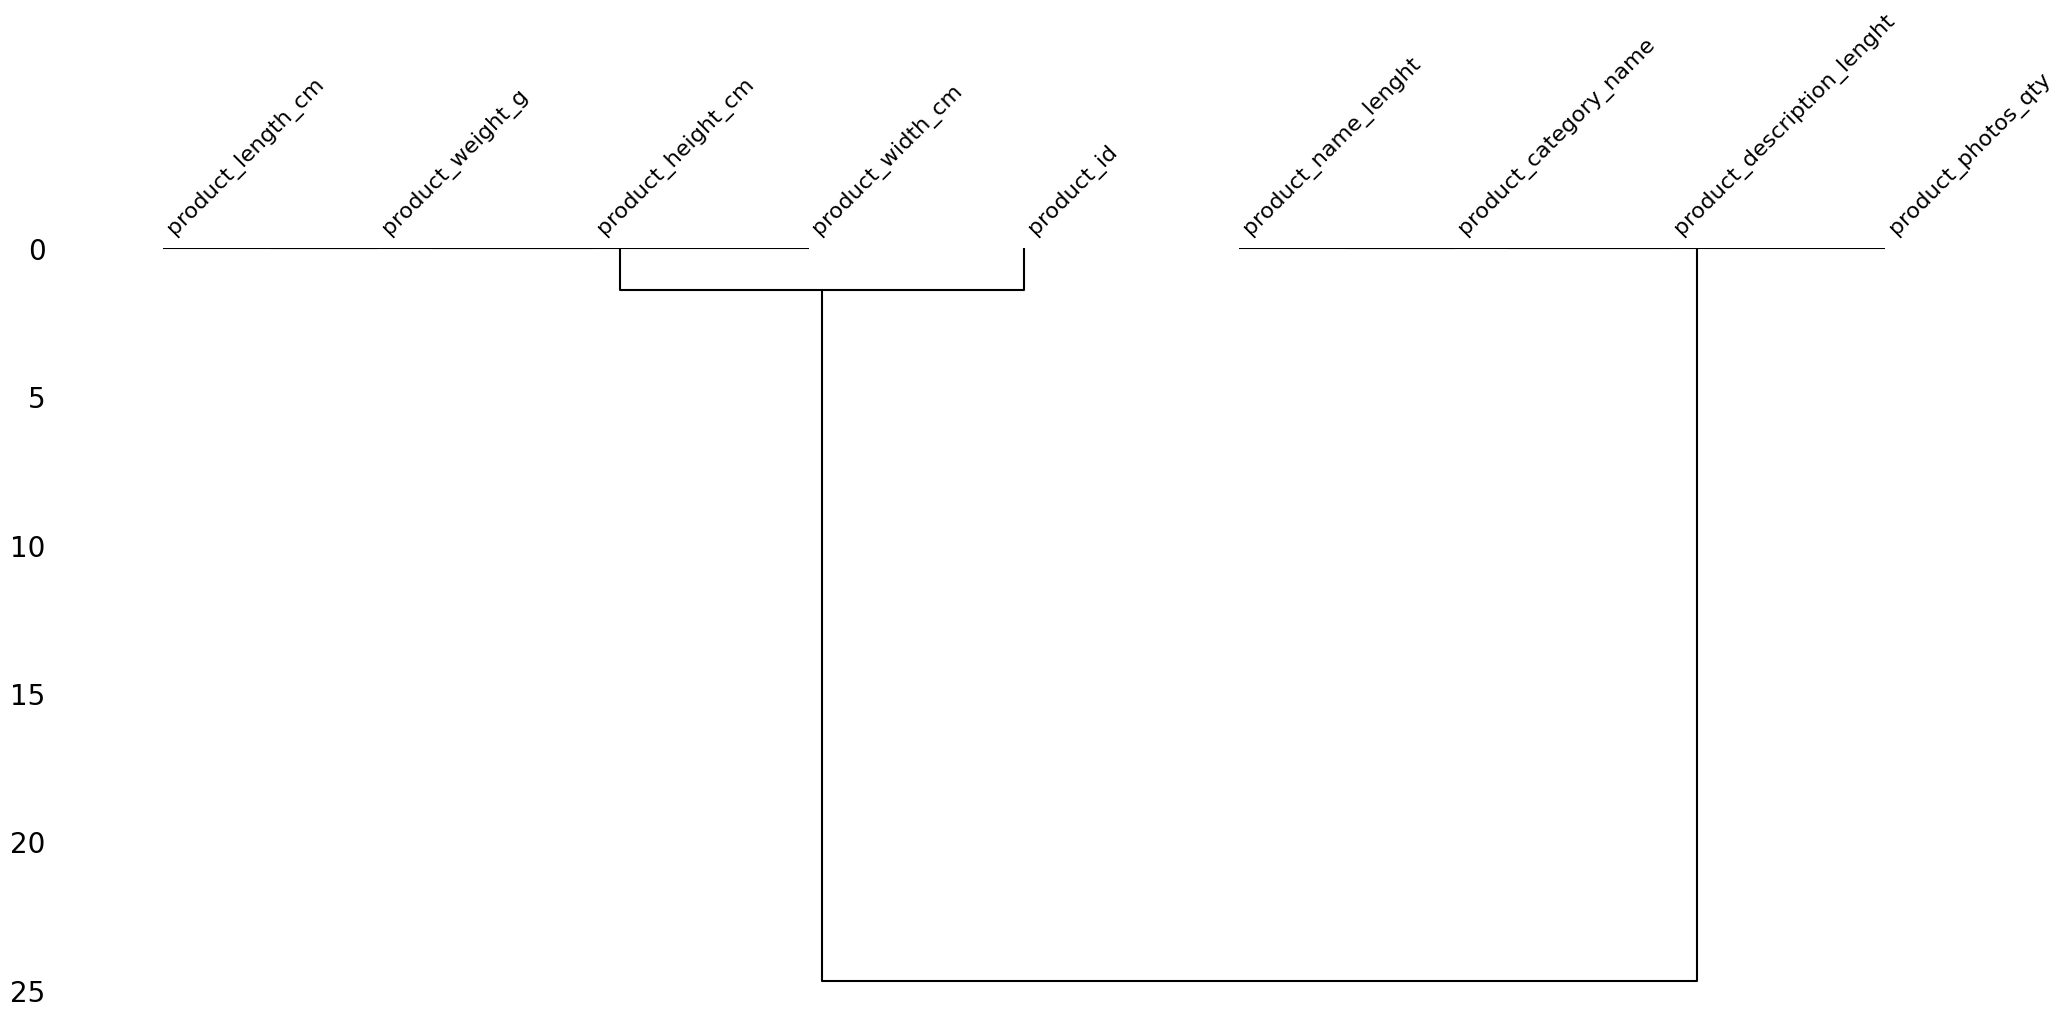

In [52]:
msno.dendrogram(products)

Kết luận: 
Missing theo pattern correlation = 1 giữa các cặp biến khẳng định biến này missing thì biến kia cũng missing

Pattern 1: product_weight_g	product_length_cm	product_height_cm	product_width_cm

Pattern 2: product_category_name	product_name_lenght	product_description_lenght	product_photos_qty	

## Check pattern 2

In [53]:
products[products["product_length_cm"].isna()]

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
8578,09ff539a621711667c43eba6a3bd8466,bebes,60.0,865.0,3.0,NaN,NaN,NaN,NaN
18851,5eb564652db742ff8f28759cd8d2652a,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Mã 5eb564652db742ff8f28759cd8d2652a	 missing type là Unit nonresponse không drop được vì nếu drop sẽ mất đi nhiều item

In [54]:
items[items["product_id"]=="5eb564652db742ff8f28759cd8d2652a"]

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
7098,101157d4fae1c9fb74a00a5dee265c25,1,5eb564652db742ff8f28759cd8d2652a,4e922959ae960d389249c378d1c939f5,2017-04-11 08:02:26,29.0,14.52
9233,1521c6bb7b1028154c8c67cf80fa809f,1,5eb564652db742ff8f28759cd8d2652a,4e922959ae960d389249c378d1c939f5,2017-04-07 10:10:16,29.0,16.05
28715,415cfaaaa8cea49f934470548797fed1,1,5eb564652db742ff8f28759cd8d2652a,4e922959ae960d389249c378d1c939f5,2017-04-07 10:35:19,29.0,14.52
28716,415cfaaaa8cea49f934470548797fed1,2,5eb564652db742ff8f28759cd8d2652a,4e922959ae960d389249c378d1c939f5,2017-04-07 10:35:19,29.0,14.52
39299,595316a07cd3dea9db7adfcc7e247ae7,1,5eb564652db742ff8f28759cd8d2652a,4e922959ae960d389249c378d1c939f5,2017-08-18 04:26:04,39.0,9.27
48424,6e150190fbe04c642a9cf0b80d83ee16,1,5eb564652db742ff8f28759cd8d2652a,4e922959ae960d389249c378d1c939f5,2017-06-30 16:45:14,39.0,16.79
48980,6f497c40431d5fb0cfbd6c943dd29215,1,5eb564652db742ff8f28759cd8d2652a,4e922959ae960d389249c378d1c939f5,2017-04-11 05:55:32,29.0,10.96
71134,a2456e7f02197951664897a94c87242d,1,5eb564652db742ff8f28759cd8d2652a,4e922959ae960d389249c378d1c939f5,2017-04-06 11:50:09,29.0,24.84
73556,a7a43f469c0d7bdb0a23a82db125aefa,1,5eb564652db742ff8f28759cd8d2652a,4e922959ae960d389249c378d1c939f5,2017-08-28 13:15:11,39.0,15.10
82767,bbfc7badbed2f1828e22b6d629201bd4,1,5eb564652db742ff8f28759cd8d2652a,4e922959ae960d389249c378d1c939f5,2017-07-18 04:04:10,39.0,11.85


Hướng xử lý điền Unknown cho category điền 0 cho numerical

In [55]:
products.loc[
    products["product_id"] == "5eb564652db742ff8f28759cd8d2652a",
    [
        "product_category_name",
        "product_name_lenght",
        "product_description_lenght",
        "product_photos_qty",
        "product_weight_g",
        "product_length_cm",
        "product_height_cm",
        "product_width_cm"
    ]
] = ["Unknown", 0, 0, 0, 0, 0, 0, 0]

In [56]:
products[products["product_id"]=="5eb564652db742ff8f28759cd8d2652a"]

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
18851,5eb564652db742ff8f28759cd8d2652a,Unknown,0.0,0.0,0.0,0.0,0.0,0.0,0.0


### Mã 09ff539a621711667c43eba6a3bd8466 hướng xử lý impute theo meadian của các biến này

In [57]:
products[products["product_id"]=="09ff539a621711667c43eba6a3bd8466"]

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
8578,09ff539a621711667c43eba6a3bd8466,bebes,60.0,865.0,3.0,NaN,NaN,NaN,NaN


In [58]:
cols = [
    "product_weight_g",
    "product_length_cm",
    "product_height_cm",
    "product_width_cm"
]

medians = products.loc[
    products["product_category_name"] == "bebes",
    cols
].median()

products.loc[
    products["product_id"] == "09ff539a621711667c43eba6a3bd8466",
    cols
] = products.loc[
    products["product_id"] == "09ff539a621711667c43eba6a3bd8466",
    cols
].fillna(medians)

In [59]:
products[products["product_id"]=="09ff539a621711667c43eba6a3bd8466"]

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
8578,09ff539a621711667c43eba6a3bd8466,bebes,60.0,865.0,3.0,850.0,33.0,16.0,25.0


## Check pattern 1

In [60]:
missing_products = products[
    products[
        [
            "product_category_name",
            "product_name_lenght",
            "product_description_lenght",
            "product_photos_qty"
        ]
    ].isna().all(axis=1)
]

In [61]:
missing_products

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
105,a41e356c76fab66334f36de622ecbd3a,NaN,NaN,NaN,NaN,650.0,17.0,14.0,12.0
128,d8dee61c2034d6d075997acef1870e9b,NaN,NaN,NaN,NaN,300.0,16.0,7.0,20.0
145,56139431d72cd51f19eb9f7dae4d1617,NaN,NaN,NaN,NaN,200.0,20.0,20.0,20.0
154,46b48281eb6d663ced748f324108c733,NaN,NaN,NaN,NaN,18500.0,41.0,30.0,41.0
197,5fb61f482620cb672f5e586bb132eae9,NaN,NaN,NaN,NaN,300.0,35.0,7.0,12.0
...,...,...,...,...,...,...,...,...,...
32515,b0a0c5dd78e644373b199380612c350a,NaN,NaN,NaN,NaN,1800.0,30.0,20.0,70.0
32589,10dbe0fbaa2c505123c17fdc34a63c56,NaN,NaN,NaN,NaN,800.0,30.0,10.0,23.0
32616,bd2ada37b58ae94cc838b9c0569fecd8,NaN,NaN,NaN,NaN,200.0,21.0,8.0,16.0
32772,fa51e914046aab32764c41356b9d4ea4,NaN,NaN,NaN,NaN,1300.0,45.0,16.0,45.0


Chiến lược impute nếu 

Với mỗi row bị missing ở:

product_category_name

product_name_lenght

product_description_lenght

product_photos_qty

Bạn dùng 4 biến:

product_weight_g

product_length_cm

product_height_cm

product_width_cm


để tìm các row giống hệt trong products.

Sau đó:

Nếu cột cần impute chỉ có đúng 1 unique value

→ impute giá trị đó.

Nếu có từ 2 unique value trở lên

→ không impute vì ambiguous.

Mục tiêu là impute Category có thể

ví dụ

In [62]:
products[
    (products['product_weight_g'] == 300.0) &
    (products['product_length_cm'] == 16.0) &
    (products['product_height_cm'] == 7.0) &
    (products['product_width_cm'] == 20.0)
]

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
128,d8dee61c2034d6d075997acef1870e9b,NaN,NaN,NaN,NaN,300.0,16.0,7.0,20.0
11283,8d98dedc3c19de17f1a090195e85d6b6,brinquedos,40.0,617.0,4.0,300.0,16.0,7.0,20.0
29248,2f9c82f3ca3b33585ac101579a28933d,brinquedos,44.0,687.0,4.0,300.0,16.0,7.0,20.0


In [63]:
cols_match = [
    "product_weight_g",
    "product_length_cm",
    "product_height_cm",
    "product_width_cm"
]

cols_impute = [
    "product_category_name",
    "product_name_lenght",
    "product_description_lenght",
    "product_photos_qty"
]

for idx, row in missing_products.iterrows():

    # tìm các record có cùng weight + dimensions
    matched = products[
        (products["product_weight_g"] == row["product_weight_g"]) &
        (products["product_length_cm"] == row["product_length_cm"]) &
        (products["product_height_cm"] == row["product_height_cm"]) &
        (products["product_width_cm"] == row["product_width_cm"])
    ]

    for col in cols_impute:

        # lấy unique value, bỏ NaN
        unique_vals = matched[col].dropna().unique()

        # chỉ impute nếu unique value = 1
        if len(unique_vals) == 1:
            products.loc[idx, col] = unique_vals[0]

In [64]:
products

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0
...,...,...,...,...,...,...,...,...,...
32946,a0b7d5a992ccda646f2d34e418fff5a0,moveis_decoracao,45.0,67.0,2.0,12300.0,40.0,40.0,40.0
32947,bf4538d88321d0fd4412a93c974510e6,construcao_ferramentas_iluminacao,41.0,971.0,1.0,1700.0,16.0,19.0,16.0
32948,9a7c6041fa9592d9d9ef6cfe62a71f8c,cama_mesa_banho,50.0,799.0,1.0,1400.0,27.0,7.0,27.0
32949,83808703fc0706a22e264b9d75f04a2e,informatica_acessorios,60.0,156.0,2.0,700.0,31.0,13.0,20.0


In [65]:
products[
    (products['product_weight_g'] == 300.0) &
    (products['product_length_cm'] == 16.0) &
    (products['product_height_cm'] == 7.0) &
    (products['product_width_cm'] == 20.0)
]

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
128,d8dee61c2034d6d075997acef1870e9b,brinquedos,NaN,NaN,4.0,300.0,16.0,7.0,20.0
11283,8d98dedc3c19de17f1a090195e85d6b6,brinquedos,40.0,617.0,4.0,300.0,16.0,7.0,20.0
29248,2f9c82f3ca3b33585ac101579a28933d,brinquedos,44.0,687.0,4.0,300.0,16.0,7.0,20.0


In [66]:
(products.isnull().sum() / len(products) * 100).round(2)

product_id                    0.00
product_category_name         1.65
product_name_lenght           1.68
product_description_lenght    1.68
product_photos_qty            1.64
product_weight_g              0.00
product_length_cm             0.00
product_height_cm             0.00
product_width_cm              0.00
dtype: float64

Còn lại điền unknown category

In [67]:
products["product_category_name"] = (
    products["product_category_name"]
    .fillna("Unknown")
)

In [69]:
(products.isnull().sum() / len(products) * 100).round(2)

product_id                    0.00
product_category_name         0.00
product_name_lenght           1.68
product_description_lenght    1.68
product_photos_qty            1.64
product_weight_g              0.00
product_length_cm             0.00
product_height_cm             0.00
product_width_cm              0.00
dtype: float64

Còn lại thì impute theo meadian hoặc thuật toán hoặc không impute

Impute meadian theo product_category_name 

In [70]:
cols = [
    "product_name_lenght",
    "product_description_lenght",
    "product_photos_qty"
]

products[cols] = (
    products.groupby("product_category_name")[cols]
    .transform(lambda x: x.fillna(x.median()))
)

In [71]:
(products.isnull().sum() / len(products) * 100).round(2)

product_id                    0.0
product_category_name         0.0
product_name_lenght           0.0
product_description_lenght    0.0
product_photos_qty            0.0
product_weight_g              0.0
product_length_cm             0.0
product_height_cm             0.0
product_width_cm              0.0
dtype: float64

So sánh distribution trước và sau impute

In [72]:
products_origin = pd.read_csv(products_file_path)

In [74]:
cols = [
    "product_name_lenght",
    "product_description_lenght",
    "product_photos_qty",
    "product_weight_g",
    "product_length_cm",
    "product_height_cm",
    "product_width_cm"
]

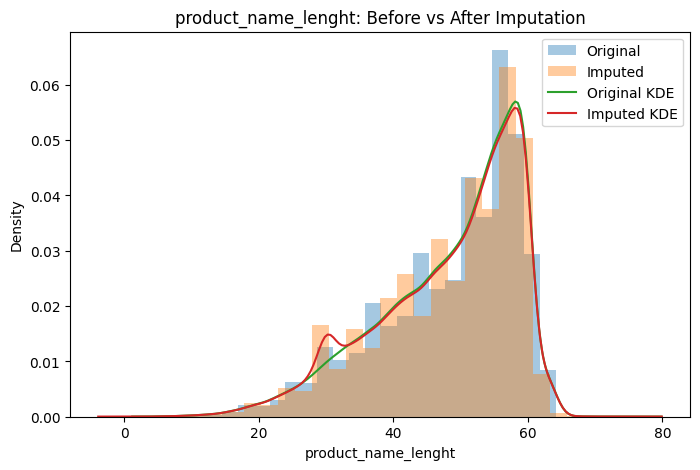

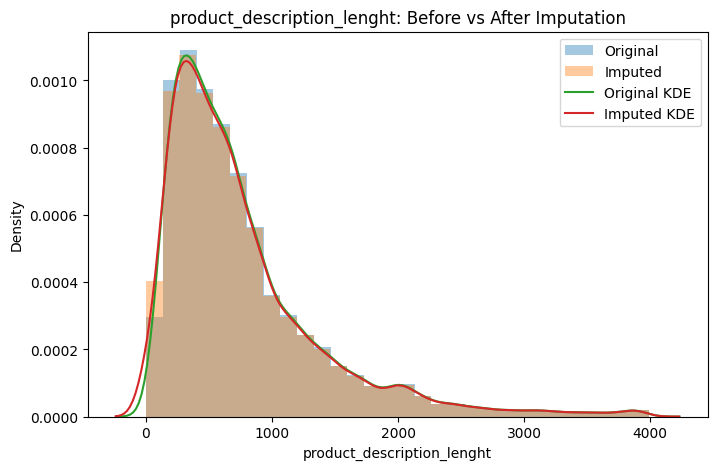

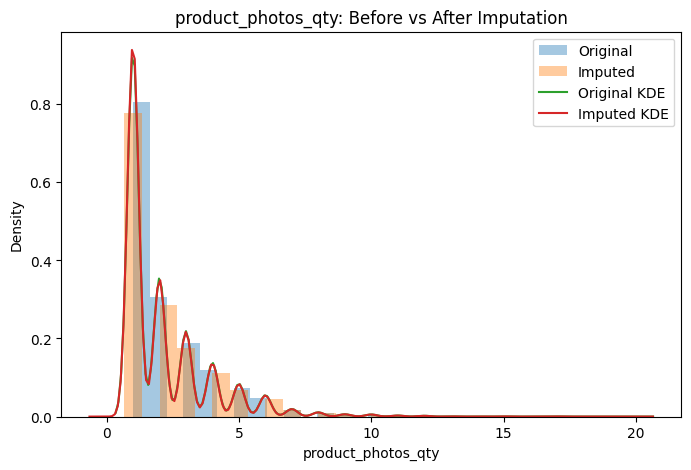

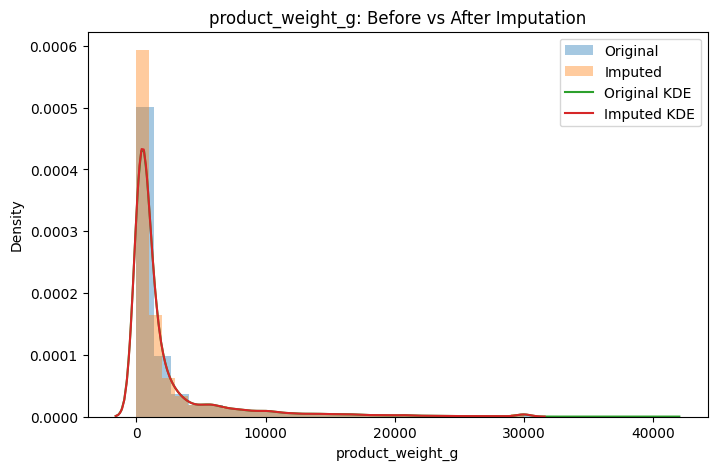

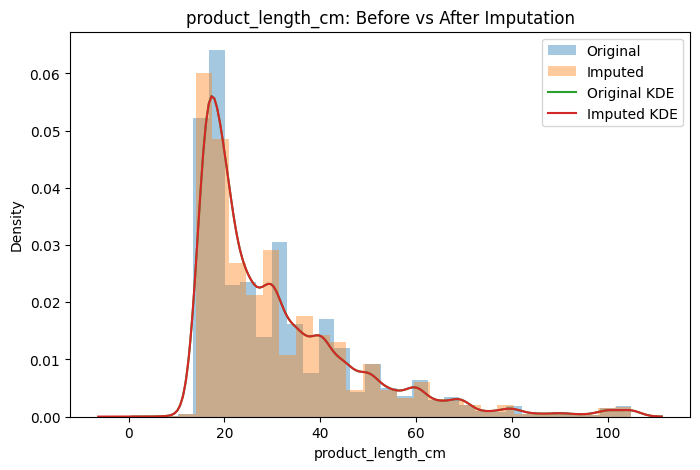

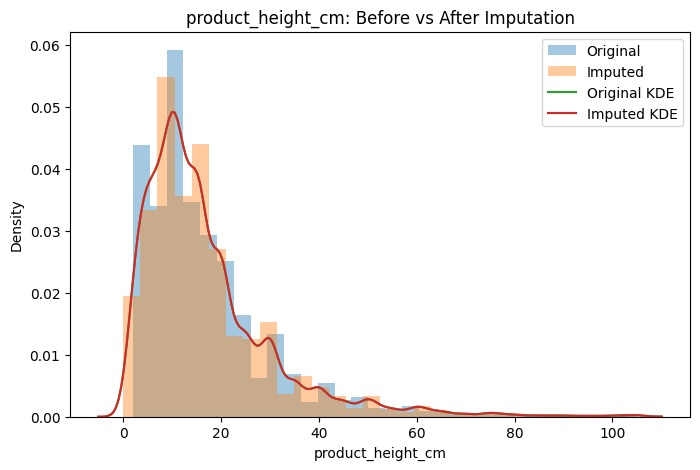

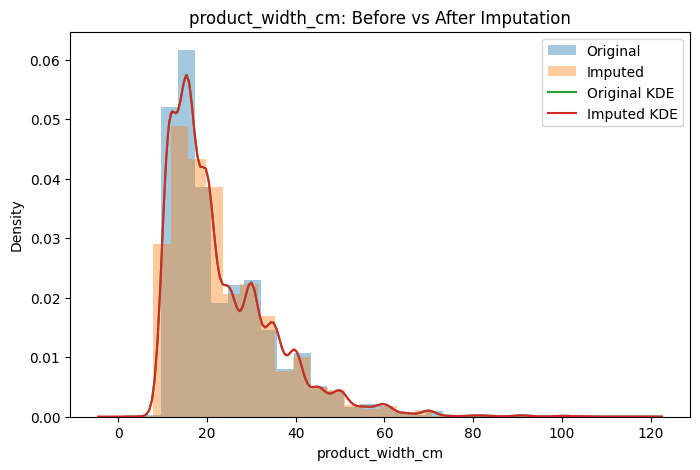

In [76]:
import matplotlib.pyplot as plt
import seaborn as sns

cols = [
    "product_name_lenght",
    "product_description_lenght",
    "product_photos_qty",
    "product_weight_g",
    "product_length_cm",
    "product_height_cm",
    "product_width_cm"
]

for col in cols:

    original = products_origin[col].dropna()
    imputed = products[col]

    plt.figure(figsize=(8,5))

    # Histogram
    plt.hist(original, bins=30, alpha=0.4, label="Original", density=True)
    plt.hist(imputed, bins=30, alpha=0.4, label="Imputed", density=True)

    # KDE
    sns.kdeplot(original, label="Original KDE")
    sns.kdeplot(imputed, label="Imputed KDE")

    plt.title(f"{col}: Before vs After Imputation")
    plt.legend()
    plt.show()

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

before = products_origin["product_category_name"].value_counts(dropna=False)
after = products["product_category_name"].value_counts(dropna=False)
df_plot = pd.DataFrame({"Before": before, "After": after})
df_plot = df_plot.sort_values("Before")

df_plot[["Before", "After"]].plot(
    kind="barh",
    figsize=(10, 14)
)

plt.xlabel("Number of Products")
plt.ylabel("Product Category")
plt.title("Product Category Distribution: Before vs After Imputation")
plt.show()

NameError: name 'df_plot' is not defined

Nhận xét: 
Tổng quan:

Imputation đã bảo toàn khá tốt phân phối của hầu hết các biến, không gây biến dạng lớn.

Chi tiết từng biến:

product_name_length: Rất tốt. Phân phối trước/sau gần như trùng nhau, chỉ mượt hơn một chút ở vùng peak (~55-60).

product_description_length: Tốt. Vẫn giữ nguyên hình dạng right-skew mạnh. Imputed bổ sung thêm một ít ở vùng giá trị rất thấp (gần 0).

product_photos_qty: Tốt. Giữ nguyên tính discrete và peak mạnh ở 0-1 ảnh.

product_weight_g: Tốt. Vẫn giữ right-skew cực mạnh. Imputed thêm một ít mật độ ở vùng trọng lượng rất nhẹ.

product_length_cm, height_cm, width_cm: Tất cả đều tốt.

Phân phối trước và sau rất giống nhau.

Peak chính (~15-25cm) được giữ nguyên.

Imputed làm mượt histogram hơn, không làm lệch shape đáng kể.